# Multi-Asset Portfolio Risk & Correlation Dynamics Across Market Regimes

> **Research Question:** How effective is diversification across major asset classes, and how does that effectiveness change during different market regimes?

---

**Asset Universe**
| Ticker | Asset Class | Role |
|--------|-------------|------|
| SPY    | Equities    | S&P 500 — growth / risk-on |
| TLT    | Bonds       | 20+ yr Treasuries — defensive |
| GLD    | Gold        | Inflation / fear hedge |
| BTC-USD | Crypto     | Speculative / emerging macro |

**Market Regimes**
- Pre-COVID (2019) — calm, trending bull market
- COVID Crash (Feb–Dec 2020) — acute liquidity crisis
- Inflation Shock (2022) — rate hike cycle, bonds + stocks both fell
- Recovery / AI Bull (2023–2024) — risk-on recovery

In [3]:
import sys, os
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

## 1. Data Pipeline

We use `yfinance` to pull adjusted closing prices.  
**Weekend / holiday handling:** Crypto trades 24/7 while equities don't.  
Solution: reindex everything to business days and forward-fill weekend BTC prices into Monday.

In [4]:
from data_loader import load_prices, REGIMES

prices = load_prices(start='2018-01-01')
prices.head()

Loaded 4 assets | 2018-01-02 → 2026-06-05 | 2199 trading days


Ticker,BTC-USD,GLD,SPY,TLT
2018-01-02,14982.099609,125.150002,236.562149,98.705711
2018-01-03,15201.000000,124.820000,238.058426,99.177589
2018-01-04,15599.200195,125.459999,239.061844,99.161880
2018-01-05,17429.500000,125.330002,240.654984,98.878700
2018-01-08,15170.099609,125.309998,241.095032,98.815804


In [5]:
# Check for any Na values
print('Missing values per asset:')
print(prices.isna().sum())
print(f'\nDate range: {prices.index[0].date()} → {prices.index[-1].date()}')
print(f'Trading days: {len(prices)}')

Missing values per asset:
Ticker
BTC-USD    0
GLD        0
SPY        0
TLT        0
dtype: int64

Date range: 2018-01-02 → 2026-06-05
Trading days: 2199


## 2. Returns Engineering

We use **log returns** throughout:

$$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$$

**Why log returns?**
- Time-additive: multi-period return = sum of daily log returns  
- Symmetric: no −100% floor 
- Standard in quantitative finance and volatility modeling

In [6]:
from returns import log_returns, portfolio_returns, cumulative_returns

log_ret  = log_returns(prices)
ew_w     = np.ones(4) / 4                         # equal-weight (25% each)
port_ret = portfolio_returns(log_ret, ew_w)

print('Daily return descriptive stats:')
log_ret.describe().round(4)

Daily return descriptive stats:


Ticker,BTC-USD,GLD,SPY,TLT
count,2198.0000,2198.0000,2198.0000,2198.0000
mean,0.0006,0.0005,0.0005,-0.0001
std,0.0400,0.0103,0.0119,0.0096
min,-0.4647,-0.1084,-0.1159,-0.0690
25%,-0.0162,-0.0043,-0.0039,-0.0056
50%,0.0006,0.0004,0.0005,0.0000
75%,0.0188,0.0056,0.0063,0.0054
max,0.2030,0.0616,0.0999,0.0725


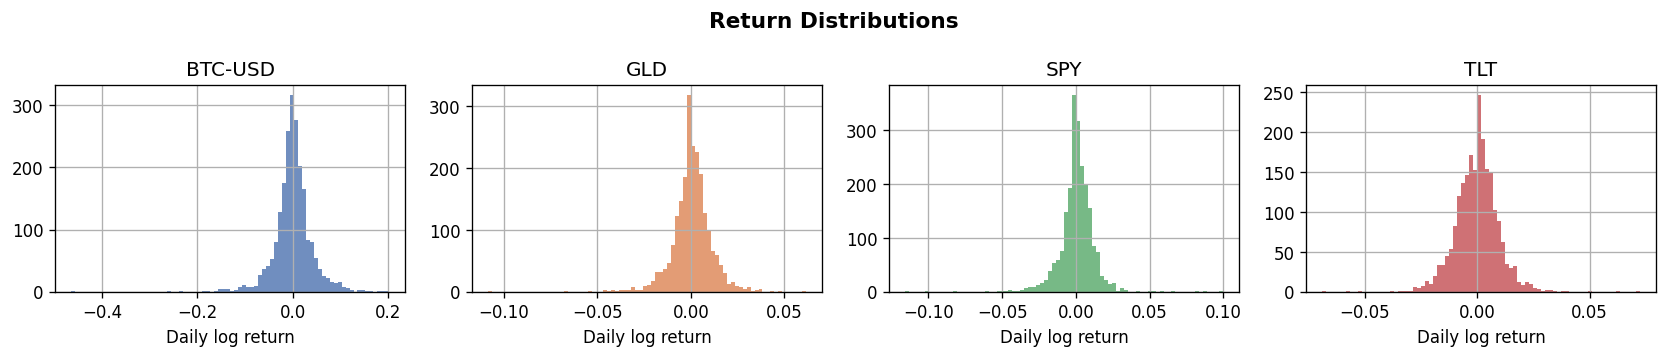

In [7]:
# Return distribution 

fig, axes = plt.subplots(1, 4, figsize=(14, 3), sharey=False)
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for ax, col, c in zip(axes, log_ret.columns, colors):
    log_ret[col].hist(bins=80, color=c, alpha=0.8, ax=ax, edgecolor='none')
    ax.set_title(col)
    ax.set_xlabel('Daily log return')

fig.suptitle('Return Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()

From these graphs, you can see that BTC has the widest distribution range. Additionally, all the distributions are centered around 0. 
- GLD is fairly symmetric and has moderate volatility. 
- Spy has fatter tails, but it is still much narrower than BTC.
- TLT is the most concentrated and has the least amount of variance.


## 3. Core Risk Metrics

### 3a. Annualised Volatility

$$\sigma_{\text{annual}} = \sigma_{\text{daily}} \times \sqrt{252}$$

Volatility = **standard deviation of returns** (not average).  
Higher σ → more uncertainty → more risk.

In [8]:
from risk_metrics import annualised_volatility, sharpe_ratio, max_drawdown, var_summary, risk_summary

vols = annualised_volatility(log_ret) * 100
print('Annualised Volatility (%)')
print(vols.round(2).to_string())

Annualised Volatility (%)
Ticker
BTC-USD    63.55
GLD        16.40
SPY        18.90
TLT        15.20


### 3b. Sharpe Ratio

$$\text{Sharpe} = \frac{E[R_p - R_f]}{\sigma_p} \times \sqrt{252}$$

Measures **reward per unit of total risk**.  
Sharpe > 1.0 is good; > 2.0 is excellent.

In [9]:
sharpes = {col: sharpe_ratio(log_ret[col]) for col in log_ret.columns}
sharpes['Portfolio (EW)'] = sharpe_ratio(port_ret)
print('Sharpe Ratios (rf = 4%)')
for k, v in sharpes.items():
    print(f'  {k:<20} {v:>6.3f}')

Sharpe Ratios (rf = 4%)
  BTC-USD               0.191
  GLD                   0.566
  SPY                   0.482
  TLT                  -0.370
  Portfolio (EW)        0.323


### 3c. Value at Risk (VaR)

**Historical VaR (95%):**
$$\text{VaR}_{95\%} = -Q_{5\%}(R)$$

Interpretation: on the worst 5% of days, the portfolio is expected to lose at least |VaR| of its value.

**Conditional VaR (CVaR / Expected Shortfall):** average of all losses *beyond* the VaR threshold — more conservative, increasingly preferred by risk managers.

In [10]:
print('Portfolio VaR metrics:')
print((var_summary(port_ret) * 100).round(3).to_string(), '%')

Portfolio VaR metrics:
Historical VaR (95%)   -1.771
Parametric VaR (95%)   -1.958
CVaR / ES    (95%)     -2.870 %


### 3d. Maximum Drawdown

$$\text{DD}_t = \frac{P_t - \max(P_{0\ldots t})}{\max(P_{0\ldots t})}$$

Peak-to-trough decline. The most intuitive risk metric for investors.

In [11]:
print('Max Drawdown:')
for col in log_ret.columns:
    mdd = max_drawdown(log_ret[col])
    print(f'  {col:<20} {mdd*100:>7.1f}%')
print(f'  {"Portfolio (EW)":<20} {max_drawdown(port_ret)*100:>7.1f}%')

Max Drawdown:
  BTC-USD                -86.4%
  GLD                    -23.9%
  SPY                    -35.7%
  TLT                    -51.1%
  Portfolio (EW)         -43.3%


### Full Risk Summary Table

In [12]:
summary = risk_summary(log_ret, port_ret)
summary

,Ann. Return (%),Ann. Volatility (%),Sharpe Ratio,Max Drawdown (%),Hist. VaR 95% (%),CVaR 95% (%)
Asset,,,,,,
BTC-USD,16.08,63.55,0.191,-86.37,-6.03,-9.76
GLD,13.21,16.40,0.566,-23.89,-1.58,-2.47
SPY,13.04,18.90,0.482,-35.75,-1.78,-2.94
TLT,-1.71,15.20,-0.370,-51.11,-1.52,-2.12
Portfolio,10.16,19.29,0.323,-43.29,-1.77,-2.87


## 4. Correlation Analysis

The Pearson correlation matrix tells us how assets move together.  
Correlation near 0 = good diversification; near 1 = no diversification benefit.

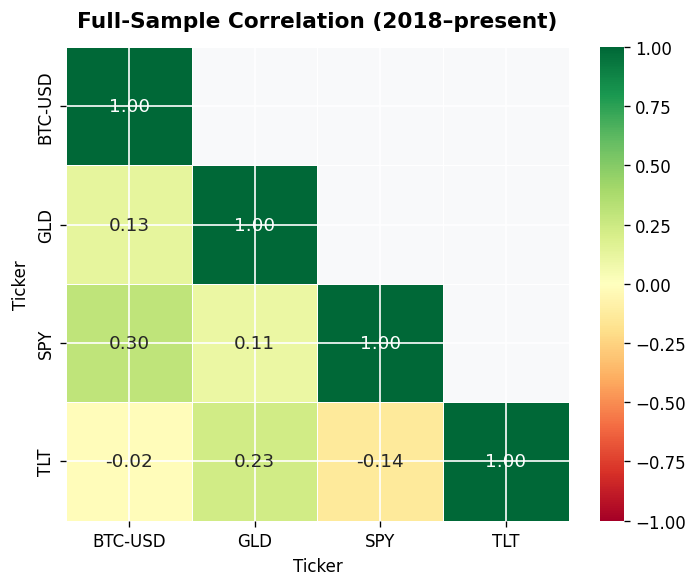

In [13]:
from correlation import correlation_matrix, regime_correlations, rolling_correlation, diversification_ratio
from visualization import plot_correlation_heatmap, plot_regime_heatmaps, plot_rolling_correlation

corr = correlation_matrix(log_ret)
plot_correlation_heatmap(corr, 'Full-Sample Correlation (2018–present)');

## 5. Regime Analysis ← THE CORE INSIGHT

> **Key hypothesis:** Diversification deteriorates during crisis periods as cross-asset correlations converge.

We test this by splitting the sample into named market regimes and comparing correlation structures.

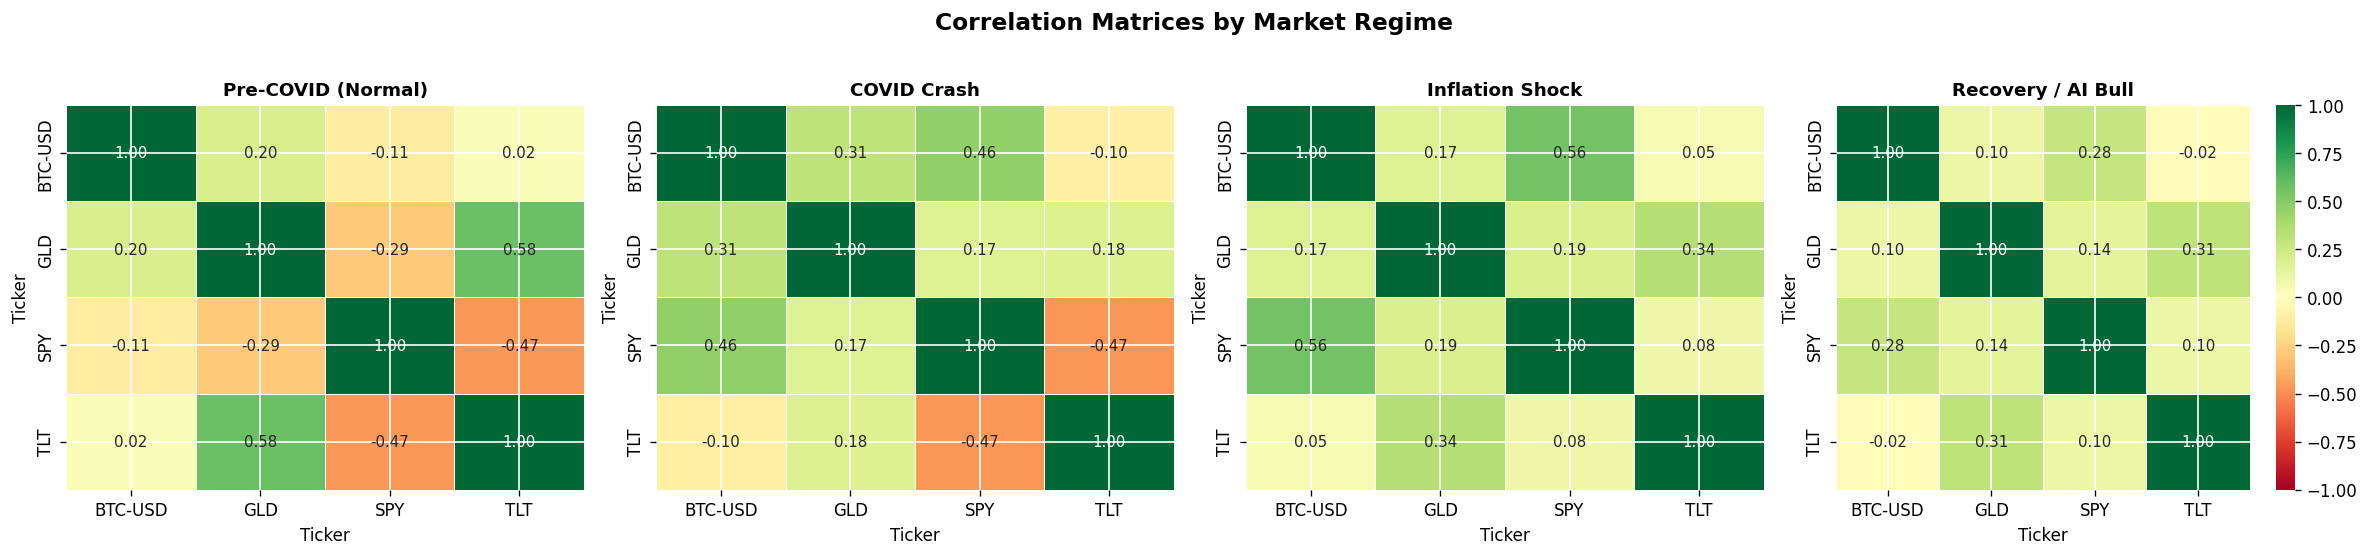

In [14]:
regime_corrs = regime_correlations(log_ret)
plot_regime_heatmaps(regime_corrs);

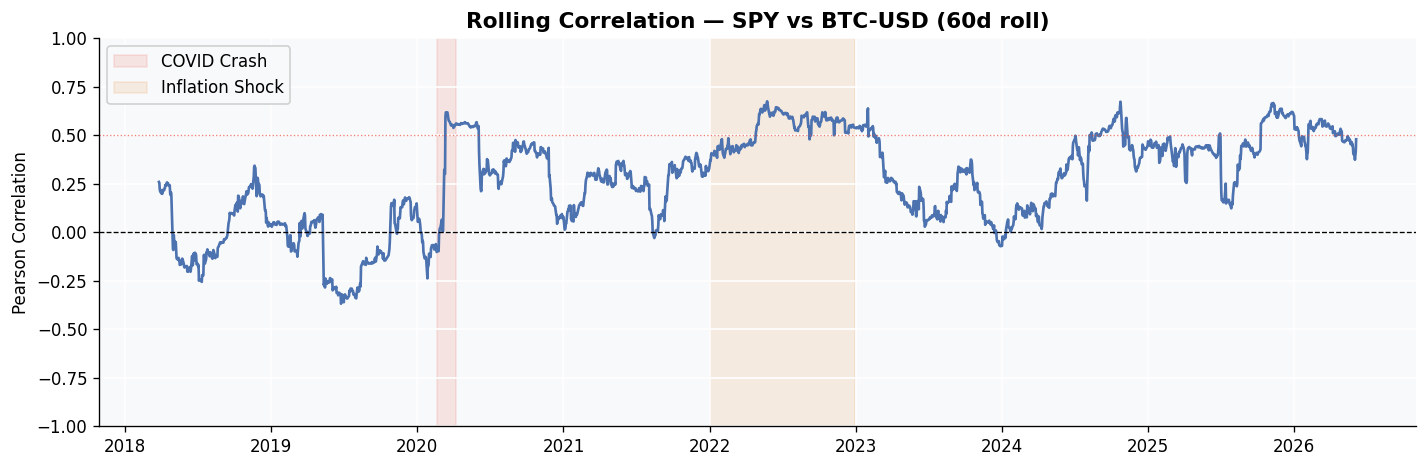

In [15]:
# Rolling 60-day SPY vs BTC correlation
from visualization import plot_rolling_correlation
roll = rolling_correlation(log_ret, 'SPY', 'BTC-USD', window=60)
plot_rolling_correlation(roll);

In [16]:
# Correlation regime shift table
from correlation import pairwise_regime_shift
print('SPY–BTC correlation across regimes:')
print(pairwise_regime_shift(log_ret, 'SPY', 'BTC-USD').to_string())
print()
print('SPY–TLT correlation across regimes:')
print(pairwise_regime_shift(log_ret, 'SPY', 'TLT').to_string())

SPY–BTC correlation across regimes:
                    Correlation
Regime                         
Pre-COVID (Normal)      -0.1135
COVID Crash              0.4626
Inflation Shock          0.5562
Recovery / AI Bull       0.2768

SPY–TLT correlation across regimes:
                    Correlation
Regime                         
Pre-COVID (Normal)      -0.4671
COVID Crash             -0.4721
Inflation Shock          0.0838
Recovery / AI Bull       0.0983


## 6. Portfolio Visualizations

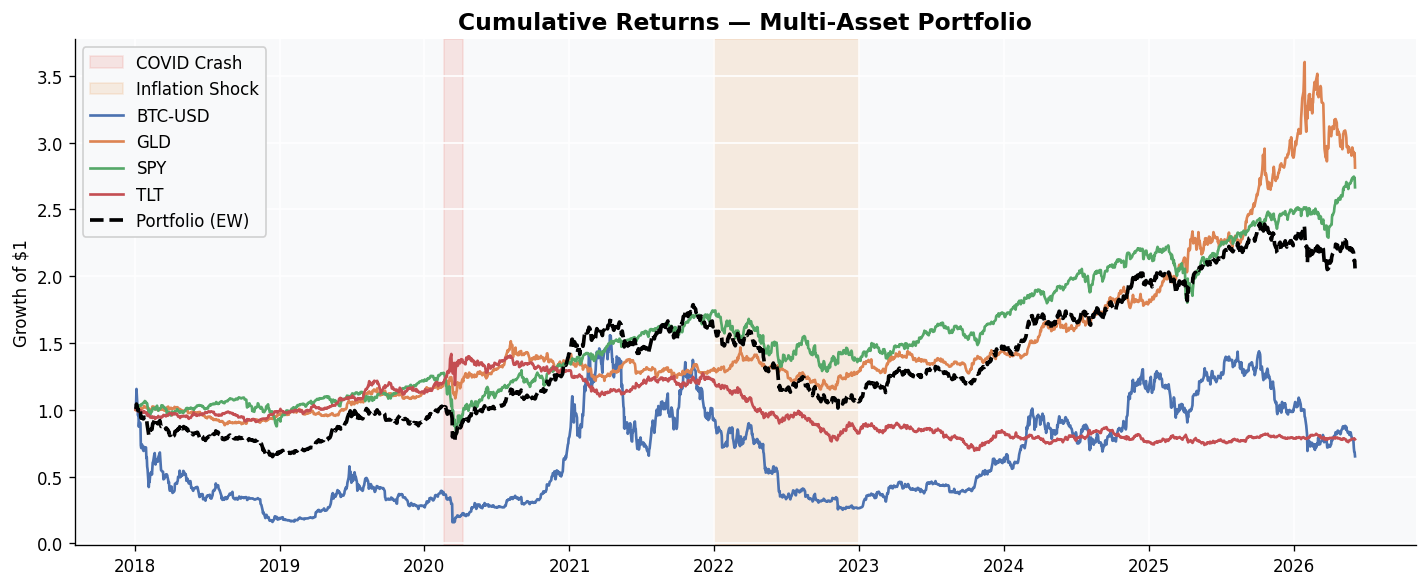

In [17]:
from visualization import plot_cumulative_returns
plot_cumulative_returns(log_ret, port_ret);

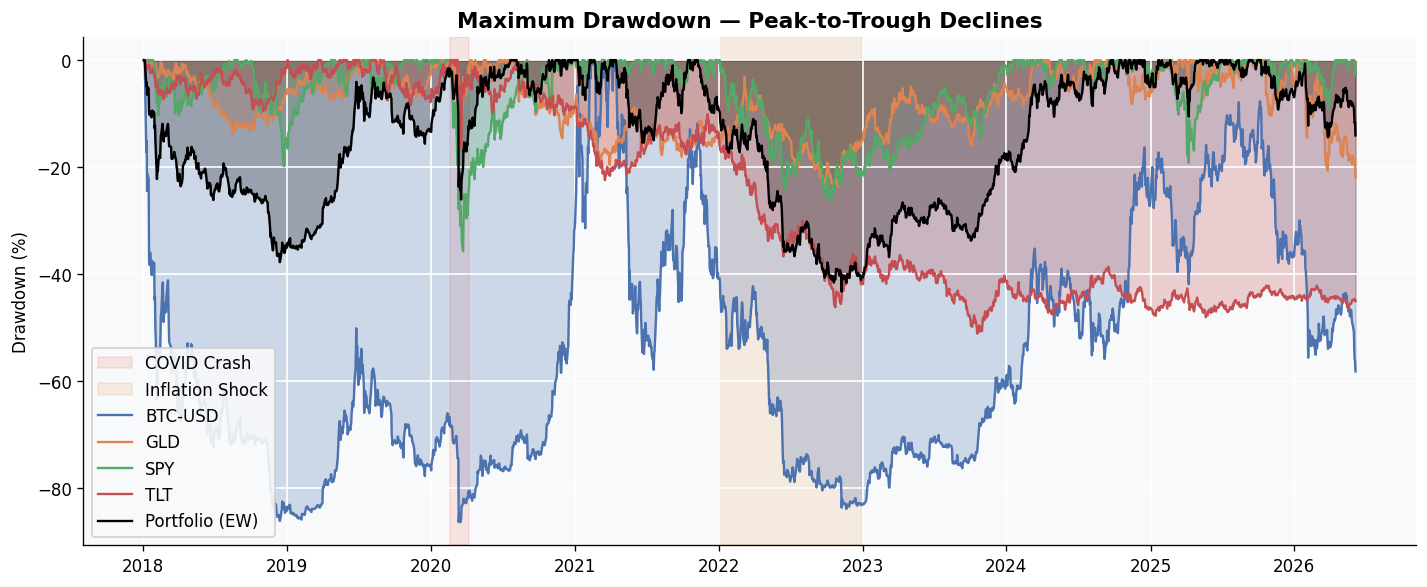

In [18]:
from risk_metrics import drawdown_series
from visualization import plot_drawdown

dd_dict = {col: drawdown_series(log_ret[col]) for col in log_ret.columns}
dd_dict['Portfolio (EW)'] = drawdown_series(port_ret)
plot_drawdown(dd_dict);

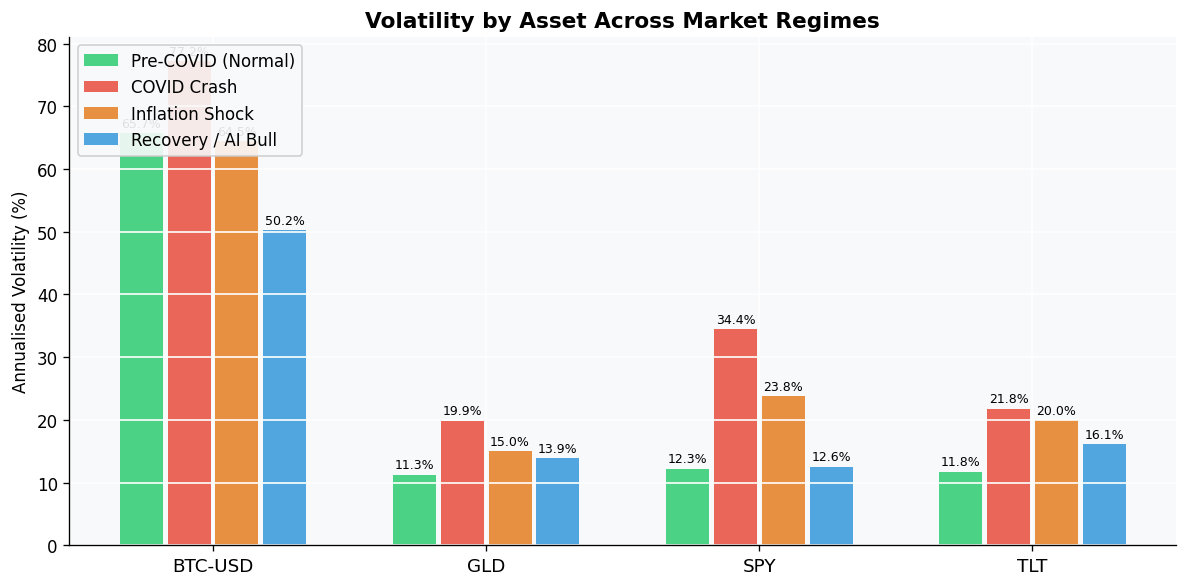

In [19]:
from visualization import plot_volatility_comparison

vol_by_regime = {}
for regime, (start, end) in REGIMES.items():
    subset = log_ret.loc[start:end]
    if len(subset) > 20:
        vol_by_regime[regime] = annualised_volatility(subset)

plot_volatility_comparison(vol_by_regime);

## 7. Key Analytical Insights

*(Fill in with actual numbers from your run — these are structural placeholders)*

1. **Correlation contagion during COVID:**  
   SPY–BTC correlation rose from ~0.0 (pre-COVID) to ~0.4 during the crash,  
   as liquidity stress caused indiscriminate selling across risk assets.

2. **Bond diversification broke down in 2022:**  
   The traditional SPY–TLT negative correlation turned positive during the inflation shock,  
   invalidating the classic 60/40 hedging thesis when both assets fell simultaneously.

3. **Gold held up as a true hedge:**  
   GLD maintained lower correlation with equities in both 2020 and 2022,  
   providing genuine diversification when other assets failed to.

4. **Equal-weight portfolio reduces tail risk:**  
   Maximum drawdown of the portfolio is significantly smaller than BTC alone,  
   demonstrating the risk-reduction benefit even from simple diversification.

5. **BTC's evolving role:**  
   Rolling correlation shows BTC shifted from largely uncorrelated (2018–2019)  
   to a high-beta risk asset post-2021, suggesting its macro character has changed.